<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-6-Improvements_NN/Untitled173.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **A First Order Differential Operator**

**Uniform sampling method**

To solve the problem
$$
f'(x) + x f(x) = e^{-x^2/2},
\qquad
f(0)=1,
$$
we approximate the solution by a neural network $f_\theta(x)$, selecting collocation points $x_k \sim \mathrm{Unif}[0,1]$, $k=1,\dots,N$, uniformly distributed in the domain. As usually, at each point we compute the residual of the differential equation
$$
r_\theta(x_k)
=
f_\theta'(x_k)
+
x_k\,f_\theta(x_k)- e^{-x_k^2/2},
$$
where the derivative is obtained via automatic differentiation. The network is trained by minimizing the loss
$$
L(\theta)
=
\frac{1}{N} \sum_{k=1}^N r_\theta(x_k)^2
+
\mu  \big(f_\theta(0)-1\big)^2, \quad \mu >0,
$$
which enforces both the differential equation in the domain and the initial condition.

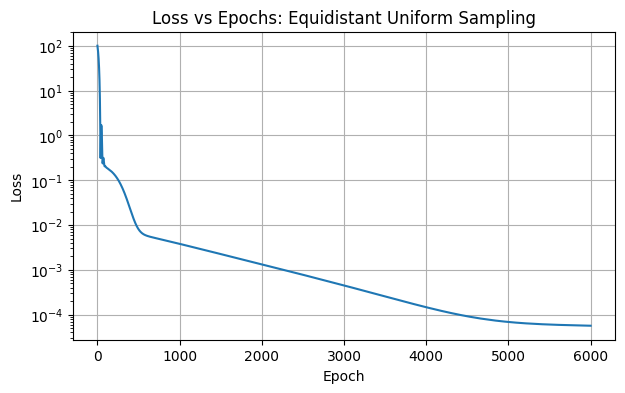

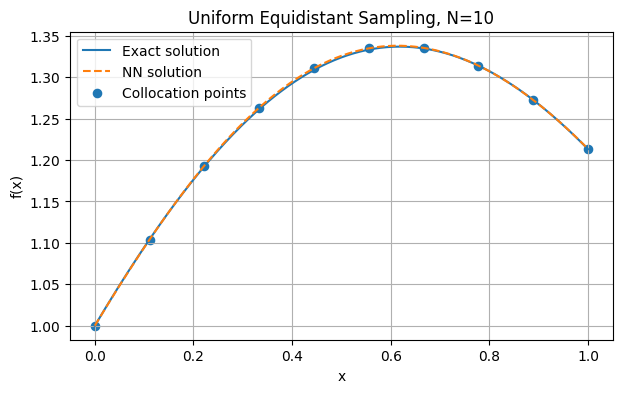

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ----------------------------
# Reproducibility
# ----------------------------
tf.random.set_seed(0)
np.random.seed(0)

# ----------------------------
# Exact solution
# ODE: f' + x f = exp(-x^2/2), f(0)=1
# Exact: f(x) = (x+1) exp(-x^2/2)
# ----------------------------
def f_exact(x):
    return (x + 1.0) * np.exp(-x**2 / 2.0)

def rhs_tf(x):
    return tf.exp(-x**2 / 2.0)

# ----------------------------
# Equidistant collocation points
# ----------------------------
N = 10
xk = np.linspace(0.0, 1.0, N).reshape(-1, 1).astype(np.float32)
xk_tf = tf.constant(xk)

# ----------------------------
# Neural network f_theta(x)
# ----------------------------
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(32, activation="tanh"),
    tf.keras.layers.Dense(32, activation="tanh"),
    tf.keras.layers.Dense(1)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

mu = 100.0
epochs = 6000
loss_history = []

# ----------------------------
# Training loop
# ----------------------------
for ep in range(epochs):
    with tf.GradientTape() as tape:

        # Compute f_theta'(x)
        with tf.GradientTape() as tape_x:
            tape_x.watch(xk_tf)
            f_val = model(xk_tf)

        f_x = tape_x.gradient(f_val, xk_tf)

        # Residual: f' + x f - exp(-x^2/2)
        residual = f_x + xk_tf * f_val - rhs_tf(xk_tf)

        loss_ode = tf.reduce_mean(tf.square(residual))

        # Initial condition f(0)=1
        x0 = tf.constant([[0.0]], dtype=tf.float32)
        f0 = model(x0)

        loss_ic = tf.square(f0 - 1.0)

        loss = loss_ode + mu * loss_ic[0, 0]

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    loss_history.append(float(loss.numpy()))

# ----------------------------
# Plot loss
# ----------------------------
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs: Equidistant Uniform Sampling")
plt.grid(True)
plt.show()

# ----------------------------
# Plot NN solution vs exact solution
# ----------------------------
x_plot = np.linspace(0.0, 1.0, 300).reshape(-1, 1).astype(np.float32)

f_nn = model(tf.constant(x_plot)).numpy().reshape(-1)
f_ex = f_exact(x_plot.reshape(-1))

plt.figure(figsize=(7, 4))
plt.plot(x_plot, f_ex, label="Exact solution")
plt.plot(x_plot, f_nn, "--", label="NN solution")
plt.scatter(xk, model(xk_tf).numpy(), s=35, label="Collocation points")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Uniform Equidistant Sampling, N=10")
plt.grid(True)
plt.legend()
plt.show()

**Importance sampling method**


To solve the previous equation
we again approximate the solution by a neural network $f_\theta(x)$ and introduce a second network $\phi_\theta(x)$ that learns a discrete probability distribution on the collocation points.

Let $x_k\in[0,1]$, $k=1,\dots,N$, be a fixed equidistant set of collocation points. We define weights
$$
w_k=\phi_\theta(x_k),\qquad w_k\ge 0,\quad \sum_{k=1}^N w_k=1,
$$
 enforced via a softmax parametrization as specified before.


The weighted loss is
$$
L(\theta)
=
\sum_{k=1}^N w_k\, r_\theta(x_k)^2
+
\mu\big(f_\theta(0)-1\big)^2.
$$
We notice a collapse of the weigth distribution and a sloppy learning of the exact solution.

Collocation points and learned weights:
x_1 = 0.0000, phi(x_k) = 0.000000
x_2 = 0.1111, phi(x_k) = 0.000001
x_3 = 0.2222, phi(x_k) = 0.000004
x_4 = 0.3333, phi(x_k) = 0.000018
x_5 = 0.4444, phi(x_k) = 0.000092
x_6 = 0.5556, phi(x_k) = 0.000519
x_7 = 0.6667, phi(x_k) = 0.003172
x_8 = 0.7778, phi(x_k) = 0.020328
x_9 = 0.8889, phi(x_k) = 0.132216
x_10 = 1.0000, phi(x_k) = 0.843650

Check normalization:
sum weights = 1.0


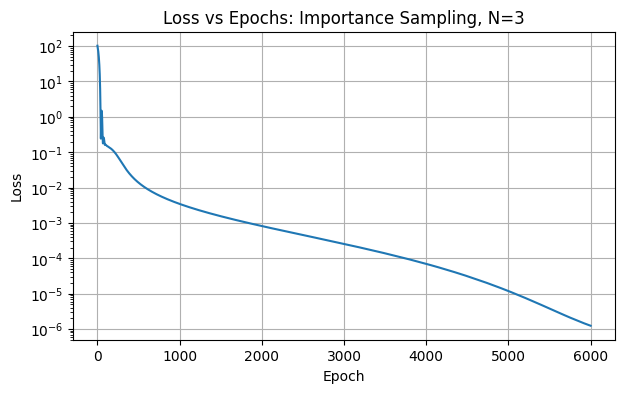

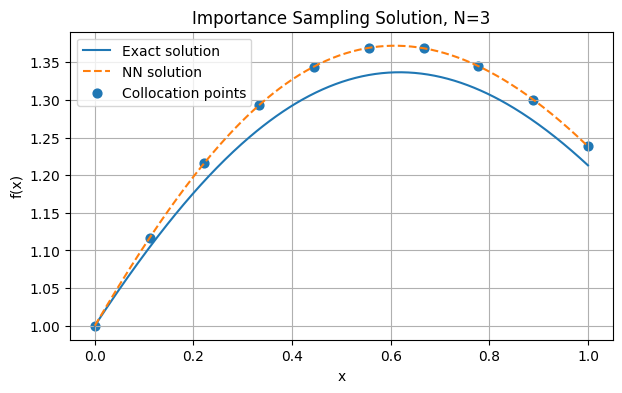

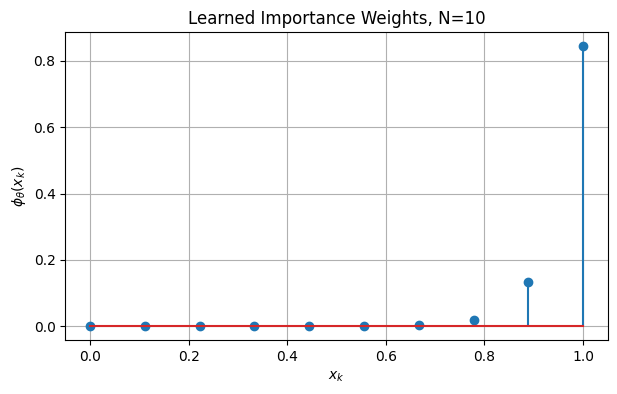

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ----------------------------
# Reproducibility
# ----------------------------
tf.random.set_seed(0)
np.random.seed(0)

# ----------------------------
# Exact solution
# ODE: f' + x f = exp(-x^2/2), f(0)=1
# Exact: f(x) = (x+1) exp(-x^2/2)
# ----------------------------
def f_exact(x):
    return (x + 1.0) * np.exp(-x**2 / 2.0)

def rhs_tf(x):
    return tf.exp(-x**2 / 2.0)

# ----------------------------
# Equidistant collocation points
# ----------------------------
N = 10
xk = np.linspace(0.0, 1.0, N).reshape(-1, 1).astype(np.float32)
xk_tf = tf.constant(xk)

# ----------------------------
# Neural network f_theta(x)
# ----------------------------
f_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(32, activation="tanh"),
    tf.keras.layers.Dense(32, activation="tanh"),
    tf.keras.layers.Dense(1)
])

# ----------------------------
# Neural network phi_theta(x)
# Produces learned weights through softmax
# ----------------------------
phi_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(32, activation="tanh"),
    tf.keras.layers.Dense(1)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

mu = 100.0
epochs = 6000
loss_history = []

# ----------------------------
# Training loop
# ----------------------------
for ep in range(epochs):
    with tf.GradientTape() as tape:

        # Compute f_theta'(x)
        with tf.GradientTape() as tape_x:
            tape_x.watch(xk_tf)
            f_val = f_model(xk_tf)

        f_x = tape_x.gradient(f_val, xk_tf)

        # Residual: f' + x f - exp(-x^2/2)
        residual = f_x + xk_tf * f_val - rhs_tf(xk_tf)

        # Learned weights phi_theta(x_k)
        raw_phi = phi_model(xk_tf)[:, 0]
        weights = tf.nn.softmax(raw_phi)

        # Importance-sampling weighted loss
        residual_sq = tf.square(residual[:, 0])
        loss_ode = tf.reduce_sum(weights * residual_sq)

        # Initial condition f(0)=1
        x0 = tf.constant([[0.0]], dtype=tf.float32)
        f0 = f_model(x0)

        loss_ic = tf.square(f0 - 1.0)

        loss = loss_ode + mu * loss_ic[0, 0]

    variables = f_model.trainable_variables + phi_model.trainable_variables
    grads = tape.gradient(loss, variables)
    optimizer.apply_gradients(zip(grads, variables))

    loss_history.append(float(loss.numpy()))

# ----------------------------
# Learned weights
# ----------------------------
raw_phi = phi_model(xk_tf)[:, 0]
weights = tf.nn.softmax(raw_phi).numpy()

print("Collocation points and learned weights:")
for i in range(N):
    print(f"x_{i+1} = {xk[i,0]:.4f}, phi(x_k) = {weights[i]:.6f}")

print("\nCheck normalization:")
print("sum weights =", np.sum(weights))

# ----------------------------
# Plot loss
# ----------------------------
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs: Importance Sampling, N=3")
plt.grid(True)
plt.show()

# ----------------------------
# Plot NN solution vs exact solution
# ----------------------------
x_plot = np.linspace(0.0, 1.0, 300).reshape(-1, 1).astype(np.float32)

f_nn = f_model(tf.constant(x_plot)).numpy().reshape(-1)
f_ex = f_exact(x_plot.reshape(-1))

plt.figure(figsize=(7, 4))
plt.plot(x_plot, f_ex, label="Exact solution")
plt.plot(x_plot, f_nn, "--", label="NN solution")
plt.scatter(xk, f_model(xk_tf).numpy(), s=40, label="Collocation points")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Importance Sampling Solution, N=3")
plt.grid(True)
plt.legend()
plt.show()

# ----------------------------
# Plot learned weights
# ----------------------------
plt.figure(figsize=(7, 4))
plt.stem(xk.reshape(-1), weights)
plt.xlabel(r"$x_k$")
plt.ylabel(r"$\phi_\theta(x_k)$")
plt.title("Learned Importance Weights, N=10")
plt.grid(True)
plt.show()

 To fix the problem, we use a mixture of the learned and uniform distributions:
$$
\psi(x_k)
=
\alpha\, \phi_\theta(x_k)
+
(1-\alpha)\,\frac{1}{N}, \qquad 0 < \alpha < 1.
$$

These modifications help maintain sufficient coverage of the domain while still benefiting from adaptive weighting.

Collocation points and learned mixed weights:
x_01 = 0.0000, w_k = 0.053855
x_02 = 0.1111, w_k = 0.056058
x_03 = 0.2222, w_k = 0.059501
x_04 = 0.3333, w_k = 0.064825
x_05 = 0.4444, w_k = 0.072934
x_06 = 0.5556, w_k = 0.085065
x_07 = 0.6667, w_k = 0.102844
x_08 = 0.7778, w_k = 0.128322
x_09 = 0.8889, w_k = 0.163970
x_10 = 1.0000, w_k = 0.212626

Check normalization:
sum weights = 0.99999994
min weight  = 0.053855415
lower bound = 0.05


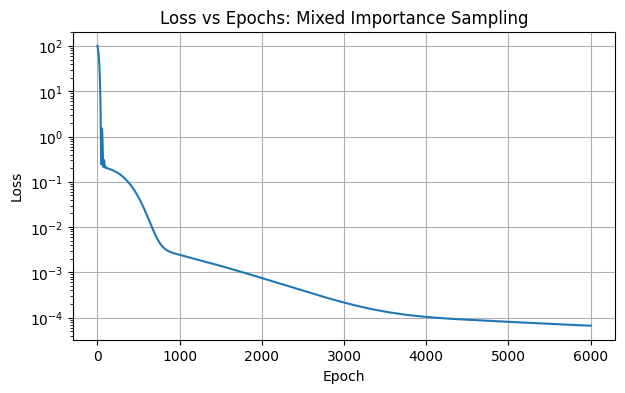

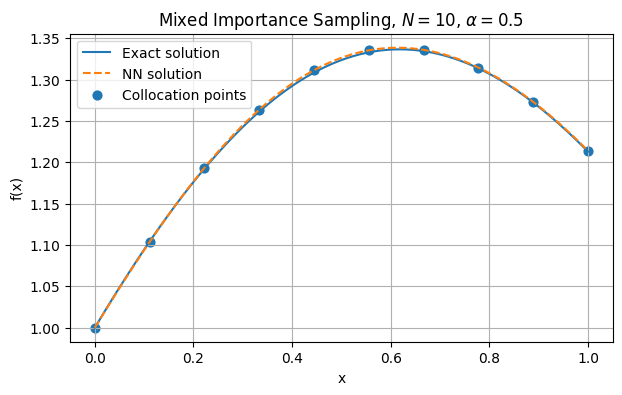

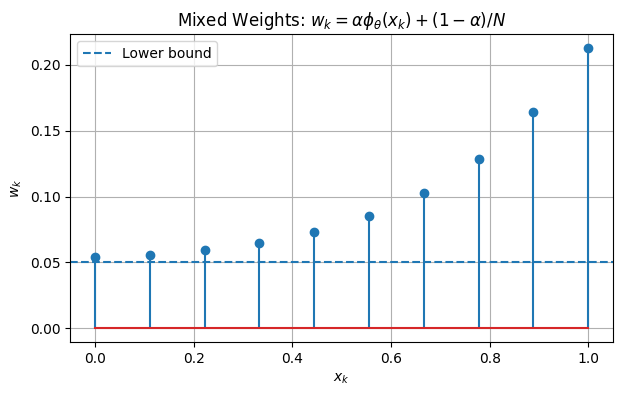

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

tf.random.set_seed(0)
np.random.seed(0)

# ----------------------------
# Exact solution
# ODE: f' + x f = exp(-x^2/2), f(0)=1
# Exact: f(x) = (x+1) exp(-x^2/2)
# ----------------------------
def f_exact(x):
    return (x + 1.0) * np.exp(-x**2 / 2.0)

def rhs_tf(x):
    return tf.exp(-x**2 / 2.0)

# ----------------------------
# Equidistant collocation points
# ----------------------------
N = 10
xk = np.linspace(0.0, 1.0, N).reshape(-1, 1).astype(np.float32)
xk_tf = tf.constant(xk)

# ----------------------------
# Neural network f_theta(x)
# ----------------------------
f_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(32, activation="tanh"),
    tf.keras.layers.Dense(32, activation="tanh"),
    tf.keras.layers.Dense(1)
])

# ----------------------------
# Neural network phi_theta(x)
# ----------------------------
phi_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(32, activation="tanh"),
    tf.keras.layers.Dense(1)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

mu = 100.0
epochs = 6000

# Mixture parameter
alpha = 0.5   # guarantees w_k >= (1-alpha)/N = 0.05

loss_history = []

for ep in range(epochs):
    with tf.GradientTape() as tape:

        # Compute f_theta'(x)
        with tf.GradientTape() as tape_x:
            tape_x.watch(xk_tf)
            f_val = f_model(xk_tf)

        f_x = tape_x.gradient(f_val, xk_tf)

        # Residual: f' + x f - exp(-x^2/2)
        residual = f_x + xk_tf * f_val - rhs_tf(xk_tf)
        residual_sq = tf.square(residual[:, 0])

        # Learned softmax weights
        raw_phi = phi_model(xk_tf)[:, 0]
        soft_weights = tf.nn.softmax(raw_phi)

        # Uniform weights
        uniform_weights = tf.ones_like(soft_weights) / N

        # Mixed weights:
        # w_k = alpha phi_theta(x_k) + (1-alpha)/N
        weights = alpha * soft_weights + (1.0 - alpha) * uniform_weights

        # Weighted residual loss
        loss_ode = tf.reduce_sum(weights * residual_sq)

        # Initial condition f(0)=1
        x0 = tf.constant([[0.0]], dtype=tf.float32)
        f0 = f_model(x0)
        loss_ic = tf.square(f0 - 1.0)

        loss = loss_ode + mu * loss_ic[0, 0]

    variables = f_model.trainable_variables + phi_model.trainable_variables
    grads = tape.gradient(loss, variables)
    optimizer.apply_gradients(zip(grads, variables))

    loss_history.append(float(loss.numpy()))

# ----------------------------
# Learned weights
# ----------------------------
raw_phi = phi_model(xk_tf)[:, 0]
soft_weights = tf.nn.softmax(raw_phi).numpy()
uniform_weights = np.ones_like(soft_weights) / N
weights = alpha * soft_weights + (1.0 - alpha) * uniform_weights

print("Collocation points and learned mixed weights:")
for i in range(N):
    print(f"x_{i+1:02d} = {xk[i,0]:.4f}, w_k = {weights[i]:.6f}")

print("\nCheck normalization:")
print("sum weights =", np.sum(weights))
print("min weight  =", np.min(weights))
print("lower bound =", (1.0 - alpha) / N)

# ----------------------------
# Plot loss
# ----------------------------
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs: Mixed Importance Sampling")
plt.grid(True)
plt.show()

# ----------------------------
# Plot NN solution vs exact solution
# ----------------------------
x_plot = np.linspace(0.0, 1.0, 300).reshape(-1, 1).astype(np.float32)

f_nn = f_model(tf.constant(x_plot)).numpy().reshape(-1)
f_ex = f_exact(x_plot.reshape(-1))

plt.figure(figsize=(7, 4))
plt.plot(x_plot, f_ex, label="Exact solution")
plt.plot(x_plot, f_nn, "--", label="NN solution")
plt.scatter(xk, f_model(xk_tf).numpy(), s=40, label="Collocation points")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(r"Mixed Importance Sampling, $N=10$, $\alpha=0.5$")
plt.grid(True)
plt.legend()
plt.show()

# ----------------------------
# Plot mixed weights
# ----------------------------
plt.figure(figsize=(7, 4))
plt.stem(xk.reshape(-1), weights)
plt.axhline((1.0 - alpha) / N, linestyle="--", label="Lower bound")
plt.xlabel(r"$x_k$")
plt.ylabel(r"$w_k$")
plt.title(r"Mixed Weights: $w_k=\alpha\phi_\theta(x_k)+(1-\alpha)/N$")
plt.grid(True)
plt.legend()
plt.show()

# **A Second Order Differential Operator**

The oscillating solution of the equation
$$
f''(x) + 0.2 f'(x) + 8 f(x)=0,
\qquad
f(0)=1, \quad f'(0)=-0.1,
$$

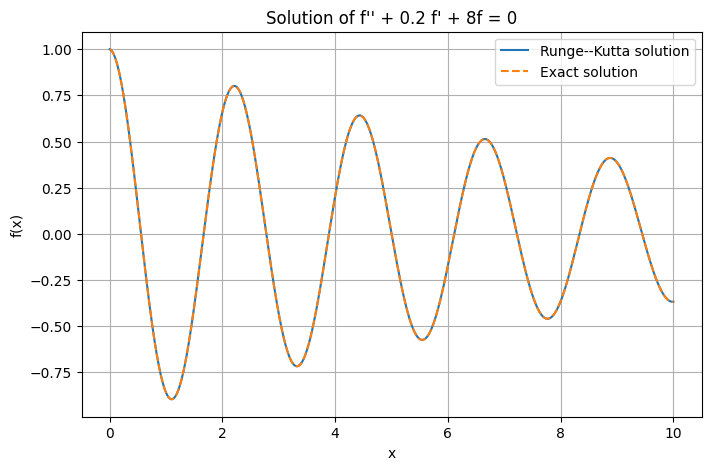

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ODE:
# f'' + 0.2 f' + 8 f = 0
#
# Set y1 = f, y2 = f'
# Then:
# y1' = y2
# y2' = -0.2 y2 - 8 y1

def system(x, y):
    y1, y2 = y
    dy1 = y2
    dy2 = -0.2 * y2 - 8.0 * y1
    return [dy1, dy2]

# Initial conditions
f0 = 1.0
fp0 = -0.1
y0 = [f0, fp0]

# Interval
x0 = 0.0
x1 = 10.0
x_eval = np.linspace(x0, x1, 1000)

# Runge--Kutta solver
sol = solve_ivp(
    system,
    [x0, x1],
    y0,
    method="RK45",
    t_eval=x_eval,
    rtol=1e-9,
    atol=1e-9
)

x = sol.t
f = sol.y[0]
fp = sol.y[1]

# Exact solution for comparison
f_exact = np.exp(-0.1 * x) * np.cos(np.sqrt(31.96) * x / 2)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x, f, label="Runge--Kutta solution")
plt.plot(x, f_exact, "--", label="Exact solution")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Solution of f'' + 0.2 f' + 8f = 0")
plt.grid(True)
plt.legend()
plt.show()

**Uniform sampling method**

To solve the problem
$$
f''(x) + 0.2 f'(x) + 8 f(x)=0,
\qquad
f(0)=1, \quad f'(0)=-0.1,
$$
we approximate the solution by a neural network $f_\theta(x)$. We select collocation points $x_k \sim \mathrm{Unif}[0,1]$, $k=1,\dots,N$, uniformly distributed in the domain. At each point we compute the residual of the differential equation
$$
r_\theta(x_k)
=
f_\theta''(x_k)
+
0.2\,f_\theta'(x_k)
+
8\,f_\theta(x_k),
$$
where the derivatives are obtained via automatic differentiation. The network is trained by minimizing the loss
$$
L(\theta)
=
\frac{1}{N} \sum_{k=1}^N r_\theta(x_k)^2
+
\mu_1 \big(f_\theta(0)-1\big)^2
+
\mu_2 \big(f_\theta'(0)+0.1\big)^2,
$$
which enforces both the differential equation in the domain and the initial conditions.

The next code considers the problem on the interval [0,1].

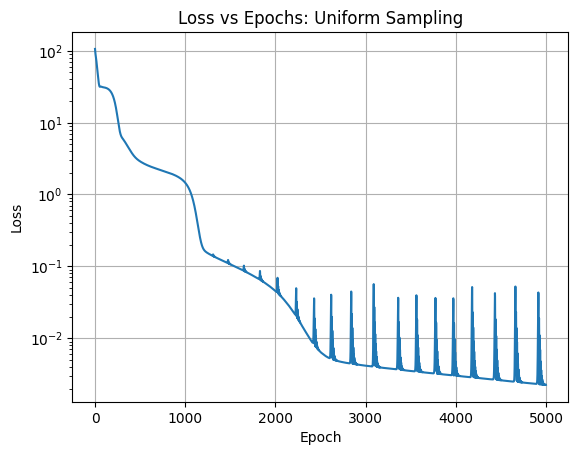

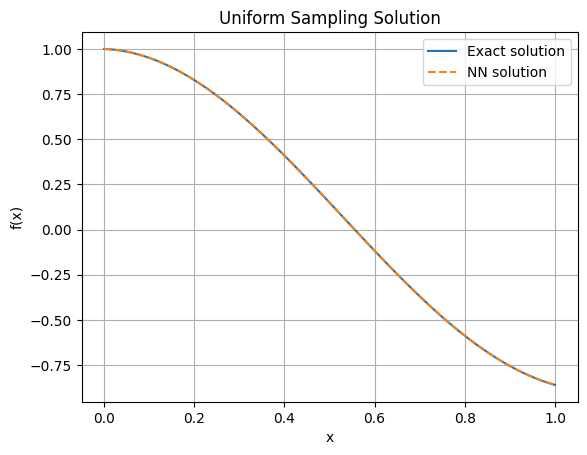

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# -------------------------------------------------
# Reproducibility
# -------------------------------------------------
tf.random.set_seed(0)
np.random.seed(0)

# -------------------------------------------------
# Exact solution
# f(x) = exp(-0.1x) cos(sqrt(31.96)x/2)
# -------------------------------------------------
def f_exact(x):
    return np.exp(-0.1 * x) * np.cos(np.sqrt(31.96) * x / 2.0)

# -------------------------------------------------
# Uniform collocation points
# -------------------------------------------------
N = 100
xk = np.random.uniform(0.0, 1.0, size=(N, 1)).astype(np.float32)
#xk = np.random.uniform(0.0, 1.0, size=(N, 1)).astype(np.float32)
xk_tf = tf.constant(xk)

# -------------------------------------------------
# Neural network f_theta(x)
# -------------------------------------------------
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(64, activation="tanh"),
    tf.keras.layers.Dense(64, activation="tanh"),
    tf.keras.layers.Dense(1)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4)

# Initial condition weights
mu1 = 100.0
mu2 = 100.0

# -------------------------------------------------
# Training loop
# -------------------------------------------------
epochs = 5000
loss_history = []

for ep in range(epochs):
    with tf.GradientTape() as tape:
        # First and second derivatives with respect to x
        with tf.GradientTape() as tape2:
            tape2.watch(xk_tf)
            with tf.GradientTape() as tape1:
                tape1.watch(xk_tf)
                f_val = model(xk_tf)
            f_x = tape1.gradient(f_val, xk_tf)
        f_xx = tape2.gradient(f_x, xk_tf)

        # ODE residual: f'' + 0.2 f' + 8f
        residual = f_xx + 0.2 * f_x + 8.0 * f_val

        loss_ode = tf.reduce_mean(tf.square(residual))

        # Initial conditions at x=0
        x0 = tf.constant([[0.0]], dtype=tf.float32)

        with tf.GradientTape() as tape0:
            tape0.watch(x0)
            f0 = model(x0)
        f0_x = tape0.gradient(f0, x0)

        loss_ic = mu1 * tf.square(f0 - 1.0) + mu2 * tf.square(f0_x + 0.1)

        loss = loss_ode + loss_ic[0, 0]

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    loss_history.append(float(loss.numpy()))

# -------------------------------------------------
# Plot loss
# -------------------------------------------------
plt.figure()
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs: Uniform Sampling")
plt.grid(True)
plt.yscale("log")
plt.show()

# -------------------------------------------------
# Plot NN solution vs exact solution
# -------------------------------------------------
x_plot = np.linspace(0.0, 1.0, 400).reshape(-1, 1).astype(np.float32)

f_nn = model(tf.constant(x_plot)).numpy().reshape(-1)
f_ex = f_exact(x_plot.reshape(-1))

plt.figure()
plt.plot(x_plot, f_ex, label="Exact solution")
plt.plot(x_plot, f_nn, "--", label="NN solution")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Uniform Sampling Solution")
plt.grid(True)
plt.legend()
plt.show()

We consider now the problem on the interval $[0,10]$:

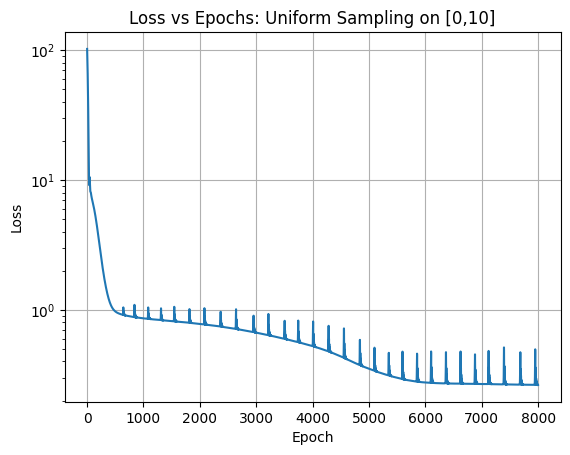

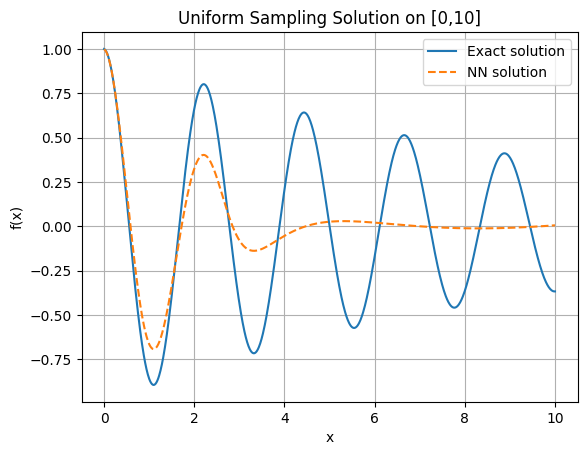

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# -------------------------------------------------
# Reproducibility
# -------------------------------------------------
tf.random.set_seed(0)
np.random.seed(0)

# -------------------------------------------------
# Exact solution on [0,10]
# f(x) = exp(-0.1x) cos(sqrt(31.96)x/2)
# -------------------------------------------------
def f_exact(x):
    return np.exp(-0.1 * x) * np.cos(np.sqrt(31.96) * x / 2.0)

# -------------------------------------------------
# Uniform collocation points on [0,10]
# -------------------------------------------------
N = 1000
#xk = np.random.uniform(0.0, 10.0, size=(N, 1)).astype(np.float32)
xk = np.random.uniform(0.0, 10.0, size=(N, 1)).astype(np.float32)
xk_tf = tf.constant(xk)

# -------------------------------------------------
# Neural network f_theta(x)
# -------------------------------------------------
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(64, activation="tanh"),
    tf.keras.layers.Dense(64, activation="tanh"),
    tf.keras.layers.Dense(1)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

mu1 = 100.0
mu2 = 100.0

# -------------------------------------------------
# Training loop
# -------------------------------------------------
epochs = 8000
loss_history = []

for ep in range(epochs):
    with tf.GradientTape() as tape:
        with tf.GradientTape() as tape2:
            tape2.watch(xk_tf)
            with tf.GradientTape() as tape1:
                tape1.watch(xk_tf)
                f_val = model(xk_tf)
            f_x = tape1.gradient(f_val, xk_tf)
        f_xx = tape2.gradient(f_x, xk_tf)

        residual = f_xx + 0.2 * f_x + 8.0 * f_val
        loss_ode = tf.reduce_mean(tf.square(residual))

        x0 = tf.constant([[0.0]], dtype=tf.float32)
        with tf.GradientTape() as tape0:
            tape0.watch(x0)
            f0 = model(x0)
        f0_x = tape0.gradient(f0, x0)

        loss_ic = mu1 * tf.square(f0 - 1.0) + mu2 * tf.square(f0_x + 0.1)
        loss = loss_ode + loss_ic[0, 0]

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    loss_history.append(float(loss.numpy()))

# -------------------------------------------------
# Plot loss
# -------------------------------------------------
plt.figure()
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs: Uniform Sampling on [0,10]")
plt.yscale("log")
plt.grid(True)
plt.show()

# -------------------------------------------------
# Plot NN solution vs exact solution
# -------------------------------------------------
x_plot = np.linspace(0.0, 10.0, 1000).reshape(-1, 1).astype(np.float32)

f_nn = model(tf.constant(x_plot)).numpy().reshape(-1)
f_ex = f_exact(x_plot.reshape(-1))

plt.figure()
plt.plot(x_plot, f_ex, label="Exact solution")
plt.plot(x_plot, f_nn, "--", label="NN solution")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Uniform Sampling Solution on [0,10]")
plt.grid(True)
plt.legend()
plt.show()

**Importance sampling method**

To solve
$$
f''(x)+0.2\,f'(x)+8f(x)=0,\qquad f(0)=1,\quad f'(0)=-0.1,
$$
we approximate the solution by a neural network $f_\theta(x)$ and introduce a second network $\phi_\theta(x)$ that learns a discrete probability distribution on the collocation points.

Let $x_k\in[0,10]$, $k=1,\dots,N$, be a fixed set of collocation points (e.g., uniformly sampled once at initialization). We define weights
$$
w_k=\phi_\theta(x_k),\qquad w_k\ge 0,\quad \sum_{k=1}^N w_k=1,
$$
typically enforced via a softmax parametrization.

At each point we compute the residual of the differential equation
$$
r_\theta(x_k)
=
f_\theta''(x_k)+0.2\,f_\theta'(x_k)+8\,f_\theta(x_k),
$$
and define the weighted loss
$$
L(\theta)
=
\sum_{k=1}^N w_k\, r_\theta(x_k)^2
+
\mu_1\big(f_\theta(0)-1\big)^2
+
\mu_2\big(f_\theta'(0)+0.1\big)^2.
$$

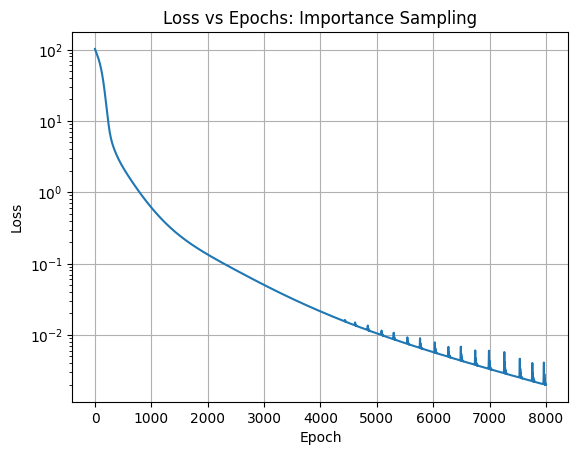

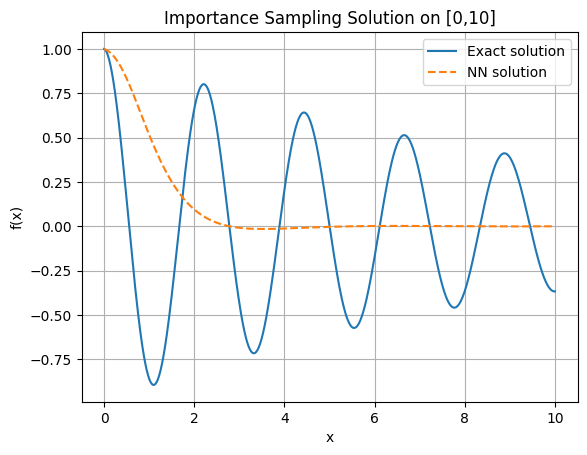

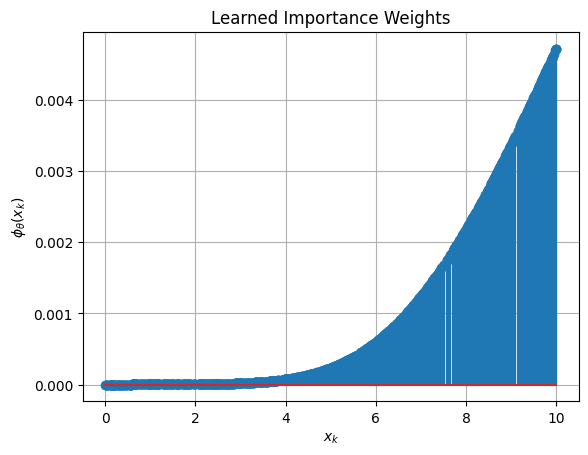

Check weights:
sum weights = 0.99999994
min weight  = 1.2291488e-07
max weight  = 0.0047249533


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# -------------------------------------------------
# Reproducibility
# -------------------------------------------------
tf.random.set_seed(0)
np.random.seed(0)

# -------------------------------------------------
# Exact solution
# f(x) = exp(-0.1x) cos(sqrt(31.96)x/2)
# -------------------------------------------------
def f_exact(x):
    return np.exp(-0.1 * x) * np.cos(np.sqrt(31.96) * x / 2.0)

# -------------------------------------------------
# Collocation points on [0,10]
# -------------------------------------------------
N = 1000
#xk = np.random.uniform(0.0, 10.0, size=(N, 1)).astype(np.float32)
xk = np.random.uniform(0.0, 10.0, size=(N, 1)).astype(np.float32)
xk_tf = tf.constant(xk)

# -------------------------------------------------
# Neural network for f_theta(x)
# -------------------------------------------------
f_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(64, activation="tanh"),
    tf.keras.layers.Dense(64, activation="tanh"),
    tf.keras.layers.Dense(1)
])

# -------------------------------------------------
# Neural network for importance weights phi_theta(x)
# -------------------------------------------------
phi_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(32, activation="tanh"),
    tf.keras.layers.Dense(1)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

mu1 = 100.0
mu2 = 100.0
epochs = 8000

loss_history = []

# -------------------------------------------------
# Training loop
# -------------------------------------------------
for ep in range(epochs):
    with tf.GradientTape() as tape:

        # Compute f, f', f''
        with tf.GradientTape() as tape2:
            tape2.watch(xk_tf)
            with tf.GradientTape() as tape1:
                tape1.watch(xk_tf)
                f_val = f_model(xk_tf)
            f_x = tape1.gradient(f_val, xk_tf)
        f_xx = tape2.gradient(f_x, xk_tf)

        # ODE residual
        residual = f_xx + 0.2 * f_x + 8.0 * f_val
        residual_sq = tf.square(residual[:, 0])

        # Learned weights
        raw_phi = phi_model(xk_tf)[:, 0]
        weights = tf.nn.softmax(raw_phi)

        # Importance-weighted residual loss
        loss_ode = tf.reduce_sum(weights * residual_sq)

        # Initial conditions
        x0 = tf.constant([[0.0]], dtype=tf.float32)

        with tf.GradientTape() as tape0:
            tape0.watch(x0)
            f0 = f_model(x0)
        f0_x = tape0.gradient(f0, x0)

        loss_ic = mu1 * tf.square(f0 - 1.0) + mu2 * tf.square(f0_x + 0.1)

        loss = loss_ode + loss_ic[0, 0]

    variables = f_model.trainable_variables + phi_model.trainable_variables
    grads = tape.gradient(loss, variables)
    optimizer.apply_gradients(zip(grads, variables))

    loss_history.append(float(loss.numpy()))

# -------------------------------------------------
# Plot loss
# -------------------------------------------------
plt.figure()
plt.plot(loss_history)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs: Importance Sampling")
plt.grid(True)
plt.show()

# -------------------------------------------------
# Plot NN solution vs exact solution
# -------------------------------------------------
x_plot = np.linspace(0.0, 10.0, 1000).reshape(-1, 1).astype(np.float32)

f_nn = f_model(tf.constant(x_plot)).numpy().reshape(-1)
f_ex = f_exact(x_plot.reshape(-1))

plt.figure()
plt.plot(x_plot, f_ex, label="Exact solution")
plt.plot(x_plot, f_nn, "--", label="NN solution")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Importance Sampling Solution on [0,10]")
plt.grid(True)
plt.legend()
plt.show()

# -------------------------------------------------
# Plot learned weights
# -------------------------------------------------
raw_phi = phi_model(xk_tf)[:, 0]
weights = tf.nn.softmax(raw_phi).numpy()

idx = np.argsort(xk.reshape(-1))
x_sorted = xk.reshape(-1)[idx]
w_sorted = weights[idx]

plt.figure()
plt.stem(x_sorted, w_sorted)
plt.xlabel(r"$x_k$")
plt.ylabel(r"$\phi_\theta(x_k)$")
plt.title("Learned Importance Weights")
plt.grid(True)
plt.show()

print("Check weights:")
print("sum weights =", np.sum(weights))
print("min weight  =", np.min(weights))
print("max weight  =", np.max(weights))